In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft

# 3章演習問題

## (1) 回転子の性質

(a) $W_N^{p+mN}={\rm exp}(-j\frac{2\pi}{N}(p+mN))={\rm exp}(-j\frac{2\pi p}{N}){\rm exp}(-j2\pi m)=W_N^{p}{\rm cos}(2\pi m)=W_N^{p}$

(b)

\begin{align}
\frac{1}{N}\Sigma_{k=0}^{N-1}W_N^{-kn} \cdot W_N^{km} &= \frac{1}{N}\Sigma_{k=0}^{N-1}{\rm exp}(j\frac{2\pi kn}{N}) \cdot {\rm exp}(-j\frac{2\pi km}{N})\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}{\rm exp}(-j\frac{2\pi k(n-m)}{N})\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}({\rm cos}(2\pi k(n-m)/N) - j{\rm sin}(2\pi k(n-m)/N))
\end{align}

$n \neq m$のとき，sinとcosの対称性から0，$m=n$のとき，
\begin{align}
&= \frac{1}{N}\Sigma_{k=0}^{N-1}({\rm cos}(2\pi k(n-m)/N) - j{\rm sin}(2\pi k(n-m)/N))\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}{\rm cos}0 = 1
\end{align}

## (2) IDFT

\begin{align}
\frac{1}{N}\Sigma_{k=0}^{N-1}X(k)W_{N}^{-kn} &= \frac{1}{N}\Sigma_{k=0}^{N-1}\Sigma_{m=0}^{N-1}x(m)W_{N}^{km}W_{N}^{-kn}\\
&= \Sigma_{m=0}^{N-1}x(m)\delta (n-m)\\
&= x(n)
\end{align}



## (3) $F_s = 16kHz$で$x(t)$を標本化して信号$x(n)$が得られたとき，

(a) 1024点DFTの正規化周波数の間隔：$2\pi/1024$

(b) 非正規化周波数の間隔：$16/1024\times 10^3=2^{-6}\times 10^3$ Hz

(c) $F_s/N \leq 25$より，$N \geq F_s/25 = 16\times 10^3 /25=640$

## (4) DFT

(a) $x(n)=1$, $n=0 \sim N-1$

\begin{align}
X(k)&= \Sigma_{n=0}^{N-1}{\rm exp}\left(-j\frac{2\pi}{N}kn\right)\\
&= \Sigma_{n=0}^{N-1} \left(e^{-j\frac{2\pi}{N}k}\right)^{n}\\
&= \left\{
\begin{aligned}
&N,\ \ \ \ k=0\\
&0,\ \ \ \ k\neq 0 \\
\end{aligned}
\right.
\end{align}

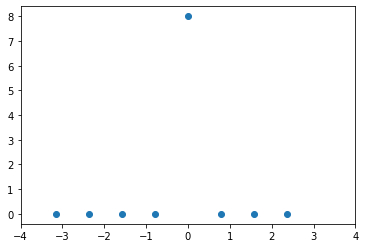

In [2]:
N = 8
omega = np.zeros(N)
for k in range(N):
    if k <= (np.floor(N/2)-1):
        omega[k] = 2.0 * np.pi * k / N
    else:
        omega[k] = -2.0 * np.pi + 2 * np.pi * k / N
    
X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == 0:
        X[k] = N
    else:
        X[k] = 0.0

plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

(b) $x(n)=(-1)^{n}$, $n=0 \sim N-1$

\begin{align}
X(k)&= \Sigma_{n=0}^{N-1}(-1)^{n}{\rm exp}\left(-j\frac{2\pi}{N}kn\right)\\
&= \left\{
\begin{aligned}
&N,\ \ \ \ k=N/2\\
&\frac{1-(-1)^{N}}{1+{\rm exp}\left( -j\frac{2\pi}{N}k\right)},\ \ \ \ k\neq N/2 \\
\end{aligned}
\right.
\end{align}

N=8のとき，k=N/2以外では分子=0なので，振幅スペクトルは０

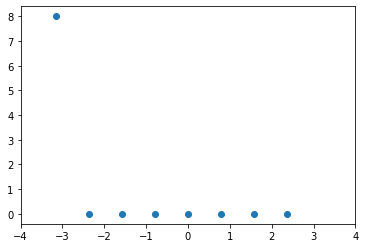

In [3]:
x = []
for n in range(N):
    xn = (-1.0)**n
    x.append(xn)
    
X = fft(x)

plt.scatter(omega, np.abs(X))
plt.xlim(-4,4)
plt.show()

(c) $x(n)=(j)^{n}$, $n=0 \sim N-1$

\begin{align}
X(k)&= \Sigma_{n=0}^{N-1}(j)^{n}{\rm exp}\left(-j\frac{2\pi}{N}kn\right)\\
&= \left\{
\begin{aligned}
&N,\ \ \ \ k=N/4\\
&\frac{1-j^{N}}{1-{\rm exp}\left( -j\frac{2\pi}{N}k\right)},\ \ \ \ k\neq N/4 \\
\end{aligned}
\right.
\end{align}

N=8のとき，k=N/4以外では分子=0なので，振幅スペクトルは０

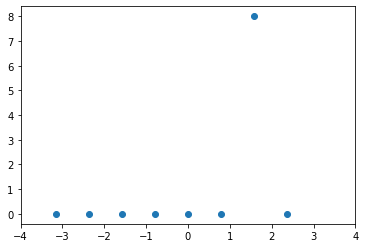

In [4]:
X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == N/4:
        X[k] = N
    else:
        X[k] = 0.0

plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

(d) $x(n)=\cos{\frac{2\pi}{N}n}, n=0 \sim N-1$

\begin{align}
\Sigma_{n=0}^{N-1}\cos{\frac{2\pi}{N}n}\exp{(-j\frac{2\pi}{N}kn)}
&= \frac{1}{2}\Sigma_{n=0}^{N-1}\left(\exp{(j\frac{2\pi}{N}n-j\frac{2\pi}{N}kn)} + \exp{(-j\frac{2\pi}{N}n-j\frac{2\pi}{N}kn)}\right)\\
&= \frac{1}{2}\Sigma_{n=0}^{N-1}\exp{\left(-j\frac{2\pi}{N}(k-1)n\right)} + \frac{1}{2}\Sigma_{n=0}^{N-1}\exp{\left(-j\frac{2\pi}{N}(k+1)n\right)}\\
&= \left\{
\begin{aligned}
&N/2,\ \ \ \ k=1, -1\\
&0,\ \ \ \ |k| \neq 1\\
\end{aligned}
\right.
\end{align}

k=-1はk=N-1のときと同じなので，k=1, N-1のときに値をもつ．

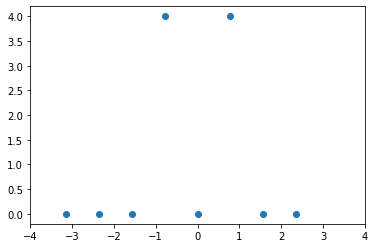

In [5]:
X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == 1 or k == N-1:
        X[k] = N / 2.0
    else:
        X[k] = 0.0

plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

(e) $x(n)={}_{N-1}C_{n}, n=0 \sim N-1$

\begin{align}
\Sigma_{n=0}^{N-1} {}_{N-1}C_{n}W_{N}^{kn} &= (1+W_{N}^{k})^{N-1}
\end{align}

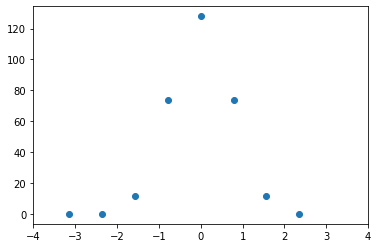

In [23]:
X = np.zeros(len(omega))
for k in range(len(omega)):
    X[k] = np.abs( (1.0 + np.exp(-1.0j * 2.0 * np.pi / N * k))**(N-1) )
    
plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

(f) 
\begin{align}
x(n)= \left\{
\begin{aligned}
&1,\ \ \ \ n=0, 1\\
&0,\ \ \ \ n=2 \sim N-1\\
\end{aligned}
\right.
\end{align}

例題3.1とほぼ同じ問題

\begin{align}
X(k)&= \Sigma_{n=0}^{1}{\rm exp}\left(-j\frac{2\pi}{N}kn\right)\\
= \left\{
\begin{aligned}
&2,\ \ \ \ k=0\\
&\frac{1-\exp{\left(-j\frac{4\pi}{N}kn\right)}}{1-\exp{\left(-j\frac{2\pi}{N}kn\right)}}
= \exp{\left( -j\frac{\pi}{N}k \right)}\frac{\sin{\frac{2\pi}{N}k}}{\sin{\frac{\pi}{N}k}},\ \ \ \ k \neq 0\\
\end{aligned}
\right.
\end{align}

振幅はexpを除いたところの絶対値

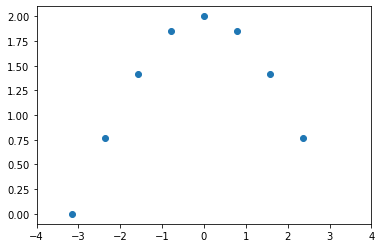

In [7]:
X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == 0:
        X[k] = 2.0
    else:
        X[k] = np.abs(np.sin(2.0*np.pi/N*k)/np.sin(np.pi/N*k))

plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

(g) $x(n)=(0.5)^{n}W_{N}^{pn}$, $n=0 \sim N-1$

例題3.2 3の結果とDFTの変調性から，

\begin{align}
X(k) = \frac{1-(0.5W_{N}^{k-p})^{N}}{1-0.5W_{N}^{k-p}}
\end{align}



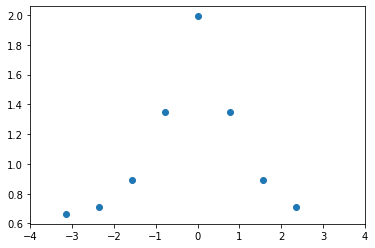

In [17]:
X = np.zeros(len(omega))
for k in range(len(omega)):
    Wk = np.exp(-1.0j * 2.0 * np.pi / N * k)
    X[k] = np.abs( (1.0 - (0.5 * Wk)**N) / (1.0 - (0.5 * Wk)) )
    
plt.scatter(omega, X)
plt.xlim(-4,4)
plt.show()

## (5) DFTの性質

1. 線形性

\begin{align}
\Sigma_{n=0}^{N-1}(a_{1}x_{1}(n) + a_{2}x_{2}(n))W_{N}^{kn} &= \Sigma_{n=0}^{N-1}a_{1}x_{1}(n)W_{N}^{kn} + \Sigma_{n=0}^{N-1}a_{2}x_{2}(n)W_{N}^{kn}\\
&= a_{1}\Sigma_{n=0}^{N-1}x_{1}(n)W_{N}^{kn} + a_{2}\Sigma_{n=0}^{N-1}x_{2}(n)W_{N}^{kn}\\
&= a_{1}X_{1}(k) + a_{2}X_{2}(k)
\end{align}

2. 周期性

\begin{align}
X(k+pN) &= \Sigma_{n=0}^{N-1}x(n)W_{N}^{(k+pN)n}\\
&= \Sigma_{n=0}^{N-1}x(n)\exp{\left(-j\frac{2\pi}{N}(kn+pNn)\right)}\\
&= \Sigma_{n=0}^{N-1}x(n)\exp{\left(-j\frac{2\pi}{N}kn\right)}\exp{\left(-j2\pi pn \right)}\\
&= \Sigma_{n=0}^{N-1}x(n)\exp{\left(-j\frac{2\pi}{N}kn\right)}\\
&= X(k)\\
\end{align}

3. 共役性

$a(n)$，$b(n)$を実数の関数として，$x(n) = a(n) + jb(n)$とすると，
\begin{align}
X(k) &= \Sigma_{n=0}^{N-1}a(n)W_{N}^{kn} + j\Sigma_{n=0}^{N-1}b(n)W_{N}^{kn}\\
&= A(k) + jB(k)
\end{align}

また，
\begin{align}
\Sigma_{n=0}^{N-1}x^{*}(n)W_{N}^{kn} &= \Sigma_{n=0}^{N-1}a(n)W_{N}^{kn} - j\Sigma_{n=0}^{N-1}b(n)W_{N}^{kn}\\
&= A(k) - jB(k)\\
&= X^{*}(k)
\end{align}

4. 対称性
\begin{align}
X^{*}(N-k) &= \Sigma_{n=0}^{N-1}x(n)\exp{\left( -j\frac{2\pi}{N}(N-k)n \right)}\\
&= \Sigma_{n=0}^{N-1}x(n)\exp{\left( -j\frac{2\pi}{N}(-k)n \right)}\exp{\left( -j2\pi n \right)}\\
&= X(-k)
\end{align}


\begin{align}
X^{*}(k) &= \Sigma_{n=0}^{N-1}x(n)\exp{\left( -j\frac{2\pi}{N}(-k)n \right)}\\
&= X(-k)
\end{align}

よって，$X(k) = X^{*}(N-k)$

5. 推移

\begin{align}
\Sigma_{n=0}^{N-1}x(n-p)W_{N}^{kn} &= \Sigma_{m=0}^{N-1}x(m)W_{N}^{k(m+p)}\\
&= W_{N}^{kp}\Sigma_{m=0}^{N-1}x(m)W_{N}^{km}\\
&= W_{N}^{kp}X(k)\\
\end{align}

6. 変調

\begin{align}
\Sigma_{n=0}^{N-1}x(n)W_{N}^{-pn}W_{N}^{kn} &= \Sigma_{n=0}^{N-1}x(n)W_{N}^{(k-p)n}\\
&= X(k-p)\\
\end{align}


7. 循環畳み込み

\begin{align}
Y(k) &= \Sigma_{n=0}^{N-1}\Sigma_{p=0}^{N-1}h(n-p)_{N}x(p)W_{N}^{kn}\\
&= \Sigma_{n=0}^{N-1}\Sigma_{p=0}^{N-1}h(n-p)_{N}x(p)W_{N}^{k(n-p)}W_{N}^{kp}\\
&= \Sigma_{p=0}^{N-1}x(p)W_{N}^{kp}\Sigma_{n=0}^{N-1}h(n-p)_{N}W_{N}^{k(n-p)}\\
&= H(k)X(k)
\end{align}

8. 乗算

\begin{align}
\Sigma_{n=0}^{N-1}h(n)x(n)W_{N}^{kn} &= \frac{1}{N}\Sigma_{n=0}^{N-1}\Sigma_{p=0}^{N-1}H(p)W_{N}^{-pn}x(n)W_{N}^{kn}\\
&= \frac{1}{N}\Sigma_{p=0}^{N-1}H(p)\Sigma_{n=0}^{N-1}x(n)W_{N}^{(k-p)n}\\
&= \frac{1}{N}\Sigma_{p=0}^{N-1}H(p)X(k-p)
\end{align}

9. 内積

\begin{align}
\Sigma_{n=0}^{N-1}h(n)x^{*}(n) &= \Sigma_{n=0}^{N-1}\frac{1}{N}\Sigma_{k=0}^{N-1}H(k)W_{N}^{-kn}x^{*}(n)\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}H(k)\Sigma_{n=0}^{N-1}x^{*}(n)W_{N}^{-kn}\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}H(k)X^{*}(k)
\end{align}

10. パーセバルの関係

\begin{align}
\Sigma_{n=0}^{N-1}|x(n)|^2 &= \Sigma_{n=0}^{N-1}x^{*}(n)x(n)\\
&= \Sigma_{n=0}^{N-1}x^{*}(n)\frac{1}{N}\Sigma_{k=0}^{N-1}X(k)W_{N}^{-kn}\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}X(k)\Sigma_{n=0}^{N-1}x^{*}(n)W_{N}^{-kn}\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}X(k)X^{*}(k)\\
&= \frac{1}{N}\Sigma_{k=0}^{N-1}|X(k)|^2\\
\end{align}

## (6) DFT

(a) $S(k) = aX(n)$

(b) $S(k) = W_{N}^{kp}X(k)$

(c) $S(k) = \frac{1}{N}\Sigma_{p=0}^{N-1}X(p)X(k-p)_{N}$

(d) $S(k) = X(k+\frac{N}{2})_{N}$

(e) $S(k) = X(k-p)_{N}/2 + X(k+p)_{N}/2$

## (7) IDFT

(a)

\begin{align}
x(n) &= \frac{1}{N}\Sigma_{k=0}^{N-1}W_{N}^{-kn}\\
&= \left\{
\begin{aligned}
& 1,\ \ \ \ n=0\\
& \frac{1}{N}\frac{1-W_{N}^{-nN}}{1-W_{N}^{-n}},\ \ \ \ n=2 \sim N-1\\
\end{aligned}
\right.\\
&= \left\{
\begin{aligned}
& 1,\ \ \ \ n=0\\
& 0,\ \ \ \ n=2 \sim N-1\\
\end{aligned}
\right.
\end{align}

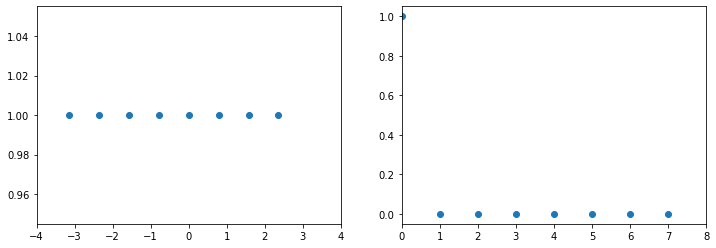

In [9]:
N = 8
X = np.ones(N)
x = np.zeros_like(X)
for n in range(N):
    if n == 0:
        x[n] = 1.0
    else:
        x[n] = 0.0

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(omega, X)
plt.xlim(-4,4)

plt.subplot(1, 2, 2)
plt.scatter(range(N), x)
plt.xlim(0, N)

plt.show()

(b)

\begin{align}
x(n) &= \frac{1}{N}\Sigma_{k=0}^{N-1}\delta(k)W_{N}^{-kn}\\
&= \frac{1}{N}
\end{align}

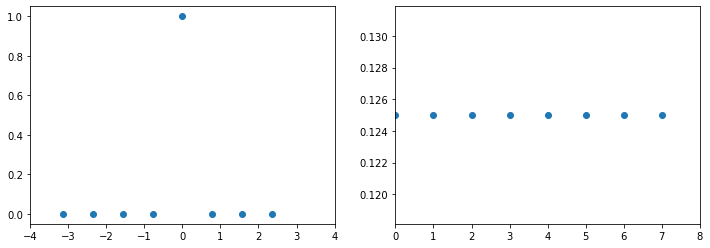

In [10]:
N = 8

X = np.zeros(N)
for k in range(N):
    if k == 0:
        X[k] = 1.0
    else:
        X[k] = 0.0

x = np.ones(N) / N

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(omega, X)
plt.xlim(-4,4)

plt.subplot(1, 2, 2)
plt.scatter(range(N), x)
plt.xlim(0, N)

plt.show()

(c)

\begin{align}
x(n) &= \frac{1}{N}\left( W_{N}^{-n} + W_{N}^{-(N-1)n} \right)\\
&= \frac{1}{N}\left( W_{N}^{-n} + W_{N}^{n} \right)\\
&= \frac{2}{N}\cos{\left( \frac{2\pi}{N}n \right)}
\end{align}

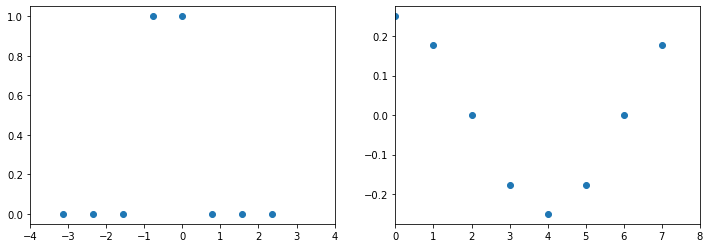

In [15]:
N = 8

x = np.zeros(N)
for n in range(N):
    x[n] = 2.0 / N * np.cos(2.0 * np.pi / N * n)

X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == 0 or k == N-1:
        X[k] = 1.0
    else:
        X[k] = 0.0

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(omega, X)
plt.xlim(-4,4)

plt.subplot(1, 2, 2)
plt.scatter(range(N), x)
plt.xlim(0, N)

plt.show()

(d)

\begin{align}
x(n) &= \frac{1}{N}\left( W_{N}^{-n} - W_{N}^{-(N-1)n} \right)\\
&= \frac{1}{N}\left( W_{N}^{-n} - W_{N}^{n} \right)\\
&= -\frac{2j}{N}\sin{\left( \frac{2\pi}{N}n \right)}
\end{align}

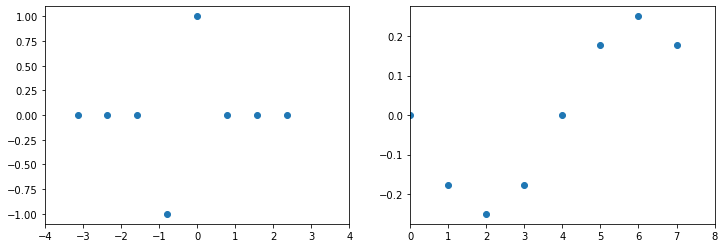

In [16]:
N = 8

x = np.zeros(N)
for n in range(N):
    x[n] = -2.0 / N * np.sin(2.0 * np.pi / N * n)

X = np.zeros(len(omega))
for k in range(len(omega)):
    if k == 0:
        X[k] = 1.0
    elif k == N - 1:
        X[k] = -1.0
    else:
        X[k] = 0.0

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(omega, X)
plt.xlim(-4,4)

plt.subplot(1, 2, 2)
plt.scatter(range(N), x)
plt.xlim(0, N)

plt.show()

## (8) 窓関数

(a)
方形窓

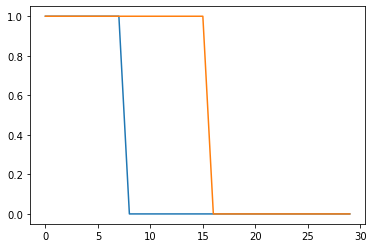

In [11]:
M = 30
rect = np.zeros(M)
for N in [8, 16]:
    for n in range(M):
        if n < N:
            rect[n] = 1.0
        else:
            rect[n] = 0.0
    plt.plot(rect)
plt.show()

ハミング窓

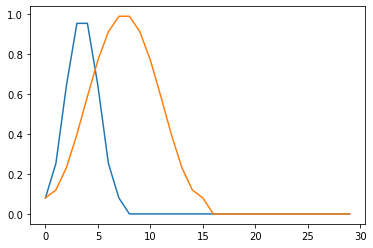

In [12]:
ham = np.zeros(M)
for N in [8, 16]:
    for n in range(M):
        if n < N:
            ham[n] = 0.54 - 0.46 * np.cos(2.0 * np.pi * n / (N - 1))
        else:
            ham[n] = 0.0
    plt.plot(ham)
plt.show()

(b) 窓のスペクトル

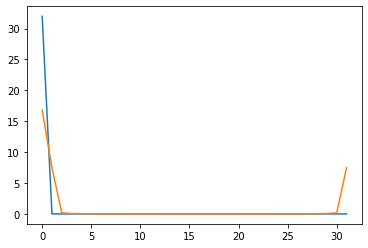

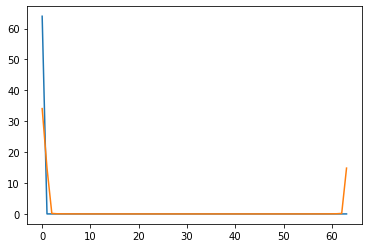

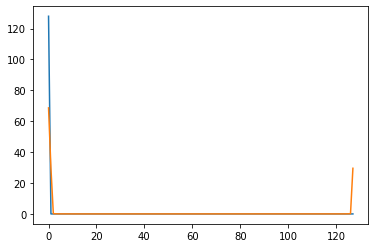

In [13]:
for N in [32, 64, 128]:
    rect = np.ones(N)
    ham = np.array([0.54 - 0.46 * np.cos(2.0 * np.pi * n /(N-1)) for n in range(N)])
    Rect = np.fft.fft(rect)
    Ham = np.fft.fft(ham)
    plt.plot(np.abs(Rect))
    plt.plot(np.abs(Ham))
    plt.show()

(c) 窓をかけた信号のスペクトル

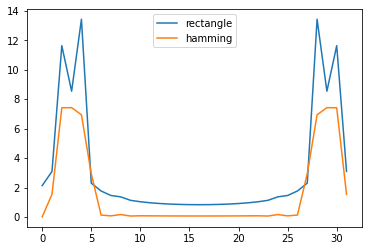

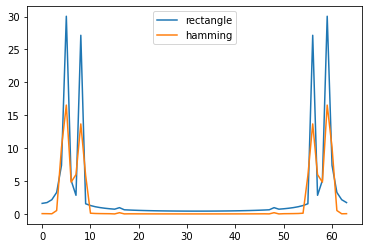

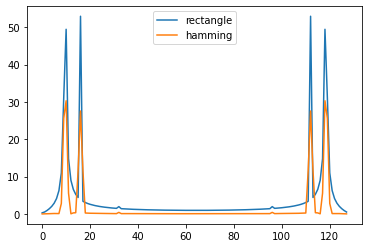

In [14]:
for N in [32, 64, 128]:
    rect = np.ones(N)
    ham = np.array([0.54 - 0.46 * np.cos(2.0 * np.pi * n /(N-1)) for n in range(N)])
    x = np.array([np.cos(0.15*np.pi*n)+0.8*np.cos(0.25*np.pi*n)+0.01*np.cos(0.5*np.pi*n) for n in range(N)])
    xrect = x * rect
    xham = x * ham
    Xrect = np.fft.fft(xrect)
    Xham = np.fft.fft(xham)
    plt.plot(np.abs(Xrect), label='rectangle')
    plt.plot(np.abs(Xham), label='hamming')
    plt.legend()
    plt.show()

(d) 窓が長いと周波数分解能が上がる．